In [1]:
import os, json, re
import zstandard as zstd
from collections import Counter, defaultdict
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from collections import defaultdict
from matplotlib import rcParams

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
rcParams['text.latex.preamble'] = r'\usepackage{amsfonts}'

model_mapper = {
    "openai/gpt-54": "GPT-5.4",
    "gemini/gemini-31-pro": "Gemini-3.1-Pro",
    "gemini/gemini-3-flash": "Gemini-3-Flash",
    "glm/glm-5": "GLM-5",
    "deepseek/deepseek_v32_think": "DeepSeek-v3.2",
    "moonshot/k25": "Kimi-2.5-Think",
    "stepfun/3.5-flash": "StepFun-3.5",
    "qwen/qwen35_397b_a17b_high": "Qwen3.5-397B",
    "xai/grok-41-fast-reasoning": "Grok-4.1-Fast",
    "openai/oss-120b": "OSS 120B",
}

def plot(model_scores, columns, column_mapper, save_file=None, label_size=18, shift_factor=0.05,
         colors=("#2768b3", "#72a7d8", "#b2dbf2"), legend=True, logos=True,
         add_values=False, values_label_size=18, width=18):     
    fig, ax = plt.subplots(figsize=(width, 6), dpi=300)

    df = pd.DataFrame.from_dict(model_scores, orient='index', columns=columns)
    df = df[df.columns.intersection(column_mapper.keys())]
    df.columns = [column_mapper[col] for col in df.columns]
    first_col = column_mapper[next(iter(column_mapper))]
    df.sort_values(by=first_col, ascending=True, inplace=True)
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Model'}, inplace=True)
    df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

    sns.barplot(
        data=df_melted, x='Model', y='Score', hue='Metric',
        palette=colors[:len(column_mapper)]
    )

    for patch in ax.patches:
        if patch.get_height() == 0 and patch.get_width() > 0:
            x = patch.get_x() + patch.get_width() / 2
            x /= len(model_mapper) - 0.6
            ax.text(
                x, 0.03, "Not Applicable",
                ha="center", va="bottom", fontsize=16, rotation=90,
                transform=ax.get_yaxis_transform()
            )
    max_value = df_melted['Score'].max()

    if add_values:
        # Dynamic text offset based on max height so it scales gracefully
        text_offset = max_value * 0.02        
        for patch in ax.patches:
            height = patch.get_height()
            if height > 0:        # skip the “N/A” zeros
                # If values are > 1, assume raw integer Elo; else assume percentages
                label_text = f'{height*100:.1f}\%' if max_value <= 1.0 else f'{int(height)}'
                ax.text(
                    patch.get_x() + patch.get_width() / 2,   # bar centre
                    height + text_offset,                    # just above the bar
                    label_text,                              # dynamic label
                    ha='center', va='bottom',
                    fontsize=values_label_size
                )

    # plt.xticks(rotation=35, ha="right")
    if logos:
        ax.set_xticklabels([''] * len(ax.get_xticks()))
    x_positions = ax.get_xticks()  # The x locations of each bar group
    models = df['Model'].unique()
    models = [model_mapper.get(model, model) for model in models]

    get_png = {
        "deepseek/deepseek_v32_think": ("notebooks/deepseek.png", 0.02, 0.00),
        "gemini/gemini-31-pro": ("notebooks/gemini.png", 0.0, 0.00),
        "gemini/gemini-3-flash": ("notebooks/gemini.png", 0.0, 0.00),
        "glm/glm-5": ("notebooks/zai.png", 0.02, 0.02),
        "moonshot/k25": ("notebooks/moonshot.png", 0.0, 0.02),
        "stepfun/3.5-flash": ("notebooks/stepfun.png", 0.0, 0.02),
        "openai/gpt-54": ("notebooks/openai.png", 0.0, 0.00),
        "openai/oss-120b": ("notebooks/openai.png", 0.0, 0.00),
        "qwen/qwen35_397b_a17b_high": ("notebooks/qwen.png", 0.04, 0),
        'xai/grok-41-fast-reasoning': ("notebooks/qwen.png", 0.0, 0)
    }
    get_png = {
        model_mapper[k]: v for k, v in get_png.items()
    }

    if logos:
        for x, model_name in zip(x_positions, models):
            if model_name in get_png:
                # Read the PNG file
                arr_img = mpimg.imread(get_png[model_name][0])
                # Scale down the image for a better fit
                imagebox = OffsetImage(arr_img, zoom=0.03)
                ab = AnnotationBbox(
                    imagebox, 
                    (x, -0.17+get_png[model_name][2]),           # place at x, near 0 (the bottom)
                    frameon=False, 
                    xycoords=('data', 'axes fraction'),  # x in data coords, y in fraction of y-axis
                    box_alignment=(0.5, 0)               # anchor the image center at the bottom center
                )
                
                # Add it to the axes
                ax.add_artist(ab)
            
            # Optionally, add text below or next to the image
            # For example, rotate the text and place it slightly below the x-axis
            ax.text(
                x + shift_factor * len(model_name) + get_png[model_name][1],  # shift right from x to avoid overlapping with bar
                -0.025,  # shift downward from 0 (in axes fraction) to avoid overlapping with bar
                model_name, 
                ha='right', 
                va='top', 
                fontsize=16,
                transform=ax.get_xaxis_transform()  # so it stays under the tick, not in data coords
            )



    plt.xlabel('')
    plt.ylabel('Elo Score', fontsize=label_size)
    plt.tick_params(axis='both', which='major', labelsize=label_size)
    if legend:
        leg = plt.legend(loc='upper left', fontsize=label_size)
        leg.get_frame().set_alpha(1)
    else:
        leg = plt.legend([], [], loc='upper left', fontsize=label_size)
        leg.set_visible(False)

    plt.tick_params(axis='y', which='both', left=False, right=False)
    sns.despine(left=True, bottom=True)
    # set background color to grey
    ax.set_facecolor((0.97,0.97,0.97))

    
    # ax.grid(axis='y', linestyle='--', alpha=1)  # Light dashed horizontal lines
    # ax.set_axisbelow(True)  # Ensure gridlines are drawn below all other plot elements
    if max_value > 1.0:
        ax.set_ylim(0, max_value * 1.15) # 15% headroom above the max value
        
        # Use matplotlib's optimal integer generation defaults
        locator = plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10])
        ax.yaxis.set_major_locator(locator)
        
        ticks = ax.get_yticks()
        # Filter negative ticks out, and format with matplotlib mathtext for style
        valid_ticks = [t for t in ticks if t >= 0 and t <= max_value * 1.2]
        
        ax.set_yticks(valid_ticks)
        ax.set_yticklabels([f'${int(t)}$' for t in valid_ticks])
        
    # Standard decimal values behaving as percentages...
    else:
        ax.set_ylim(0, max_value + 0.1)
        n = int((max_value + 0.1) * 5)
        ax.set_yticks([i / 5 for i in range(n + 1)])
        ax.set_yticklabels([f'${i * 20}\%$' for i in range(n + 1)])
    if save_file:
        fig.savefig(save_file, bbox_inches='tight')

<>:66: SyntaxWarning: invalid escape sequence '\%'
<>:167: SyntaxWarning: invalid escape sequence '\%'
<>:66: SyntaxWarning: invalid escape sequence '\%'
<>:167: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1883002/3944763475.py:66: SyntaxWarning: invalid escape sequence '\%'
  label_text = f'{height*100:.1f}\%' if max_value <= 1.0 else f'{int(height)}'
/tmp/ipykernel_1883002/3944763475.py:167: SyntaxWarning: invalid escape sequence '\%'
  ax.set_yticklabels([f'${i * 20}\%$' for i in range(n + 1)])


In [2]:
columns = [
    "valid_correct_conciseness",
    "correct_Cognitive Simplicity",
    "correct_Computational Ease",
    "correct_conciseness",
    "answer_correct_Cognitive Simplicity",
    "answer_correct_Computational Ease",
    "answer_correct_conciseness",
    "all_accuracy",
    "all_Cognitive Simplicity",
    "all_Computational Ease",
    "all_conciseness",
    "Number Theory_correct_Cognitive Simplicity",
    "Number Theory_correct_Computational Ease",
    "Number Theory_correct_conciseness",
    "Geometry_correct_Cognitive Simplicity",
    "Geometry_correct_Computational Ease",
    "Geometry_correct_conciseness",
    "Combinatorics_correct_Cognitive Simplicity",
    "Combinatorics_correct_Computational Ease",
    "Combinatorics_correct_conciseness",
    "Calculus_correct_Cognitive Simplicity",
    "Calculus_correct_Computational Ease",
    "Calculus_correct_conciseness",
    "Algebra_correct_Cognitive Simplicity",
    "Algebra_correct_Computational Ease",
    "Algebra_correct_conciseness",
    "xai_correct_conciseness",
    "accuracy",
    "anti_verbosity_accuracy",
    "anti_verbosity_2_accuracy",
    "anti_verbosity_conciseness",
    "anti_verbosity_2_conciseness",
]

elos = {
    "openai/gpt-54": [
        1378,
        1330, 1615, 1379,
        1211, 1390, 1219,
        1562, 1122, 1292, 1194,
        1362, 1618, 1402,
        1227, 1648, 1498,
        1487, 1534, 1238,
        1261, 1674, 1027,
        1375, 1648, 1639, 1360,
        86.4, 
        None, None, None, None
    ],
    "deepseek/deepseek_v32_think": [
        1264,
        1269, 1052, 1250,
        1282, 1137, 1211,
        1145, 1311, 1152, 1180,
        1281, 1159, 1125,
        1318,  996, 1526,
        1171, 1156, 1120,
        1238,  703, 1041,
        1233,  854, 1489, 1227,
        47.9, 
        36.4, 30.4, 1952, 2529
    ],
    "gemini/gemini-3-flash": [
        1181,
        1257, 1313, 1181,
        1283, 1337, 1366,
        1080, 1254, 1268, 1328,
        1230, 1441, 1207,
        1286, 1334, 1207,
        1221, 1121, 1448,
        1054, 1082, 1123,
        1296, 1494, 1271, 1195,
        29.8,
        38.0, 34.8, 1459, 1890
    ],
    "qwen/qwen35_397b_a17b_high": [
        1117,
        1221, 1508, 1118,
        1326, 1527, 1185,
        1066, 1339, 1453, 1146,
        1180, 1431, 1195,
        1184, 1489, 1018,
        1303, 1560,  849,
        1418, 1948, 1719,
        1351, 1664, 1159, 1186,
        29.3,
        None, None, None, None
    ],
    "glm/glm-5": [
         940,
        1195,  865,  937,
        1204,  926,  871,
        1191, 1242,  940,  844,
        1192,  914, 1106,
        1196,  786,  916,
        1279, 1004,  902,
        1019,  890,  783,
        1013,  794,  957, 866,
        49.1,
        None, None, None, None
    ],
    "gemini/gemini-31-pro": [
         257,
        1177, 1046,  272,
        1086, 1002,  415,
        1337, 1022,  956,  499,
        1211,  971,  129,
        1116, 1077,  195,
        1166, 1020,  414,
        1350, 1341,  240,
        1457, 1060,  104, 356,
        60.7,
        None, None, None, None
    ],
    "xai/grok-41-fast-reasoning": [
        1473,
        1163, 1012, 1470,
        1300, 1231, 1604,
        1092, 1325, 1278, 1590,
        1103, 1080, 1372,
        1164,  961, 1236,
        1207,  999, 1662,
        1319, 1195, 2043,
        1161, 1148, 1455, 1503,
        31.4,
        None, None, None, None
    ],
    "stepfun/3.5-flash": [
        1401,
        1161, 1220, 1405,
        1171, 1203, 1405,
        1117, 1265, 1463, 1628,
        1186, 1003, 1443,
        1193, 1253, 1400,
        1101, 1383, 1442,
        1190, 1154, 1502,
        1064, 1001, 1183, 1521,
        41.1,
        None, None, None, None
    ],
    "openai/oss-120b": [
        1453,
        1116, 1119, 1452,
        1070, 1064, 1306,
        1180, 1055, 1045, 1246,
        1210, 1187, 1554,
        1133, 1144, 1429,
        1037, 1014, 1405,
        1005, 1112, 1319,
        1012, 1121, 1362, 1435,
        34.3,
        33.5, 31.9, 2024.7, 2477.2
    ],
    "moonshot/k25": [
        1537,
        1110, 1251, 1535,
        1067, 1181, 1418,
        1230, 1065, 1154, 1344,
        1045, 1195, 1468,
        1182, 1311, 1575,
        1028, 1207, 1519,
        1146,  900, 1204,
        1039, 1217, 1380, 1449,
        53.6,
        38.0, 34.8, 1736, 2469
    ]
}

# Validity Difference Plot

/tmp/ipykernel_1883002/3944763475.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * len(ax.get_xticks()))


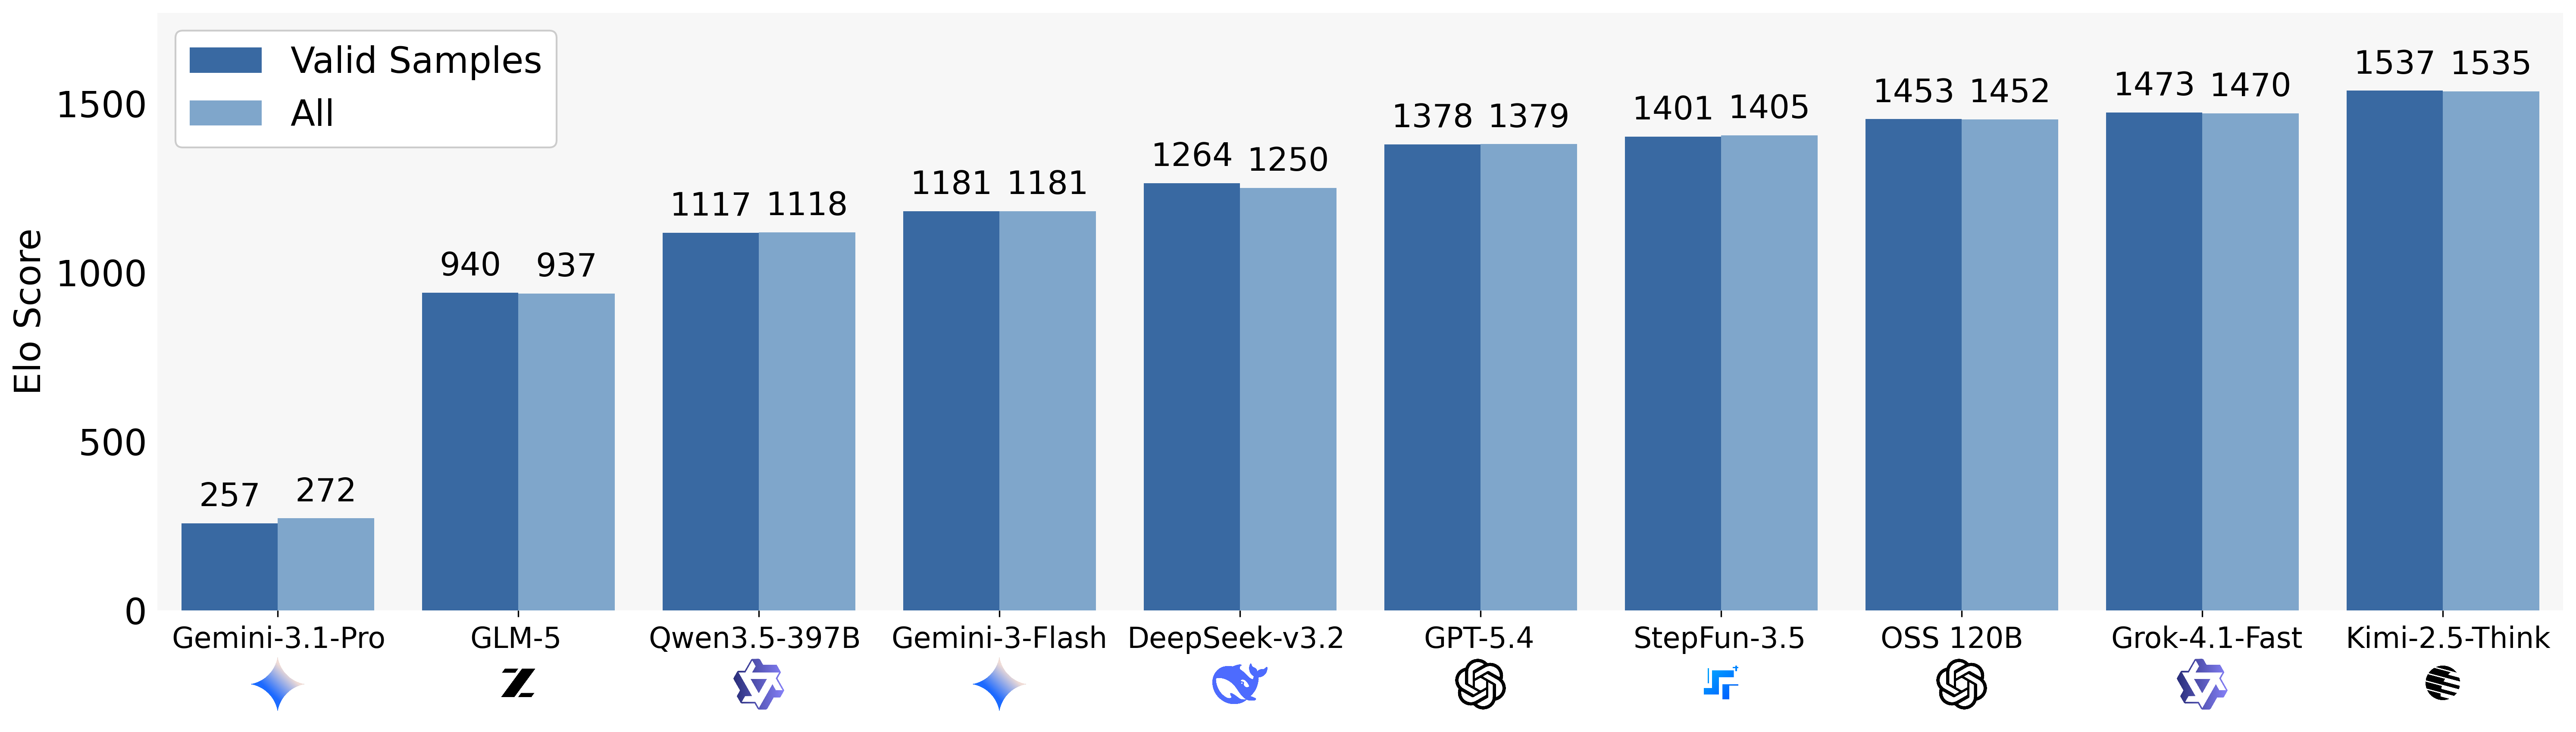

In [3]:
plot(elos, columns, {
    "valid_correct_conciseness": "Valid Samples",
    "correct_conciseness": "All"
}, save_file="figures/validity_comparison.pdf", width=24,add_values=True, values_label_size=18, shift_factor=0.032, label_size=20)

# Rephraser Conceiseness Comparison

/tmp/ipykernel_1883002/3944763475.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * len(ax.get_xticks()))


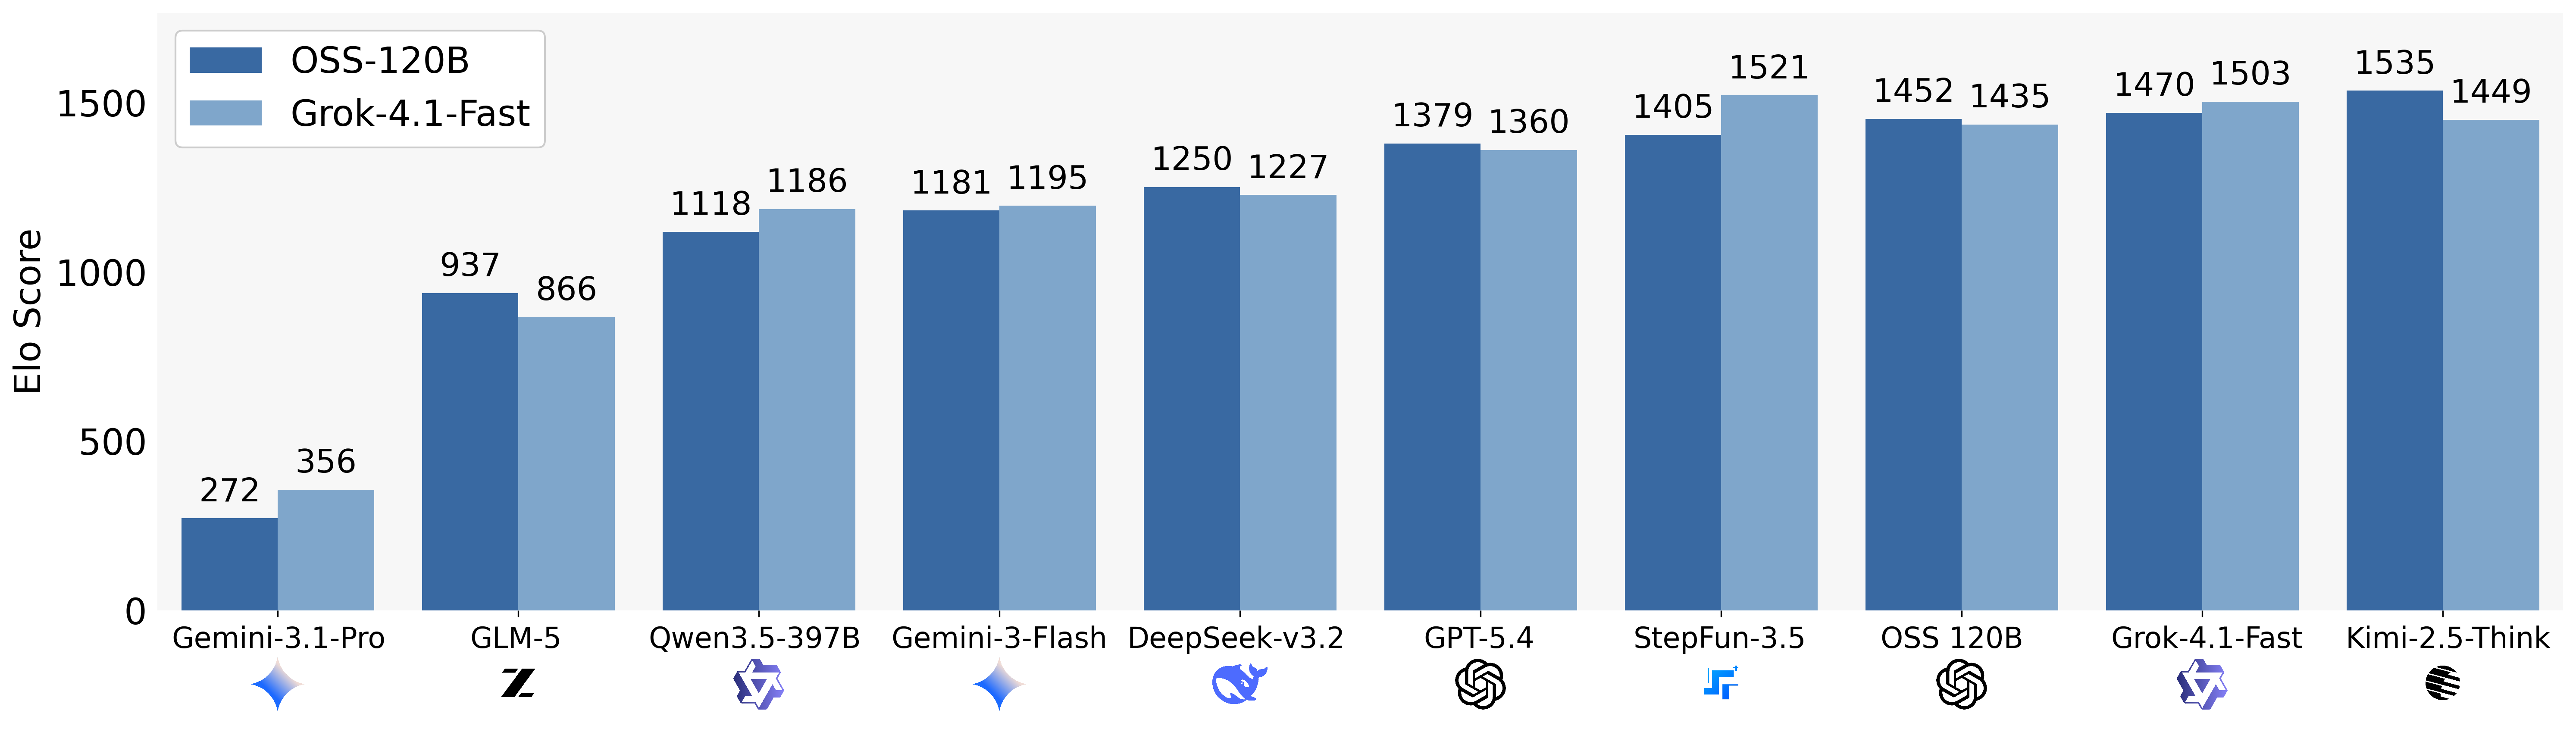

In [4]:
plot(elos, columns, {
    "correct_conciseness": "OSS-120B",
    "xai_correct_conciseness": "Grok-4.1-Fast",
    
}, save_file="figures/rephraser_comparison.pdf", width=24,add_values=True, values_label_size=18, shift_factor=0.032, label_size=20)

# Unique Human Solutions Plot

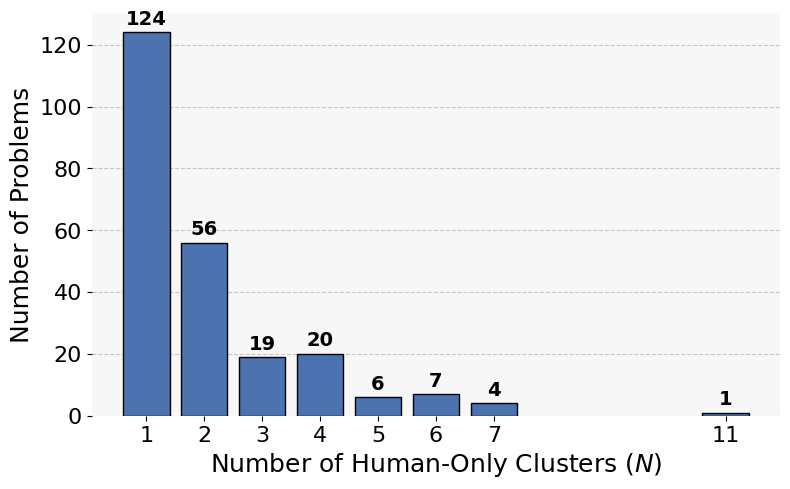

In [11]:
N_values = [1,2,3,4,5,6,7,11]
problem_counts = [124,56,19,20,6,7,4,1]

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor((0.97, 0.97, 0.97))
sns.despine(left=True, bottom=True)
bars = plt.bar(N_values, problem_counts, color='#4C72B0', edgecolor='black', zorder=2)

plt.xlabel('Number of Human-Only Clusters ($N$)', fontsize=18)
plt.ylabel('Number of Problems', fontsize=18)
plt.xticks(N_values, fontsize=16) 
plt.yticks(fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + max(problem_counts)*0.01, 
             int(yval), ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("figures/human_cluster_distribution.pdf", bbox_inches='tight')
plt.show()

# Conciseness Prompt Evolution

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

def plot_prompt_progression(
    model_scores,
    cols,
    metric_x,
    metric_y,
    model_mapper,
    prompts=("correct", "verbosity_rephrase_2", "verbosity_rephrase_3"),
    save_file=None,
    label_size=22,
    marker_size=260,
    width=14,
    min_points=2,
):
    sns.set_style("white")
    colors = ["#2768b3", "#b2dbf2", "#e35f62", "#fcd96e", "#76c562"]
    fig, ax = plt.subplots(figsize=(width, 8), dpi=300)

    prompt_markers = {
        "correct": "o",
        "verbosity_rephrase_2": "s",
        "verbosity_rephrase_3": "D",
    }

    def strip_prompt_prefix(name, prompt):
        pref = f"{prompt}_"
        return name[len(pref):] if name.startswith(pref) else name

    base_x = strip_prompt_prefix(metric_x, "correct")
    base_y = strip_prompt_prefix(metric_y, "correct")

    def resolve_col(prompt, base_metric, original_metric):
        candidates = [
            f"{prompt}_{base_metric}",                    # preferred
            original_metric if prompt == "correct" else None,  # fallback
            base_metric if prompt == "correct" else None,      # fallback
        ]
        for c in candidates:
            if c is not None and c in cols:
                return c
        return None

    # Build long table
    rows = []
    for model, scores in model_scores.items():
        if model not in model_mapper:
            continue
        for p in prompts:
            x_col = resolve_col(p, base_x, metric_x)
            y_col = resolve_col(p, base_y, metric_y)
            if x_col is None or y_col is None:
                continue

            x_val = scores[cols.index(x_col)]
            y_val = scores[cols.index(y_col)]

            rows.append({
                "model": model,
                "Model": model_mapper[model],
                "prompt": p,
                "prompt_order": prompts.index(p),
                "x": x_val,
                "y": y_val,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No matching columns found. Check prompt/metric naming in `cols`.")

    # Keep valid points only; drop sparse models
    df["valid"] = df["x"].notna() & df["y"].notna()
    valid_counts = df.groupby("model")["valid"].sum()
    keep_models = valid_counts[valid_counts >= min_points].index
    df = df[df["model"].isin(keep_models) & df["valid"]].copy()

    if df.empty:
        raise ValueError(f"No models have at least {min_points} valid points.")

    df = df.sort_values(["model", "prompt_order"])

    # Per-model colors
    model_order = (
        df[["model", "Model"]]
        .drop_duplicates()
        .sort_values("Model")["model"]
        .tolist()
    )
    model_color = {m: colors[i % len(colors)] for i, m in enumerate(model_order)}

    # Draw trajectory + arrows per model
    for model, g in df.groupby("model"):
        g = g.sort_values("prompt_order")
        c = model_color[model]

        # line
        ax.plot(g["x"], g["y"], color=c, alpha=0.95, linewidth=2.5, zorder=2)

        # arrows between consecutive valid prompt points
        for i in range(len(g) - 1):
            x0, y0 = g.iloc[i][["x", "y"]]
            x1, y1 = g.iloc[i + 1][["x", "y"]]
            ax.annotate(
                "",
                xy=(x1, y1),
                xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=c,
                    lw=1.8,
                    alpha=0.9,
                    shrinkA=6,
                    shrinkB=6,
                    mutation_scale=12
                ),
                zorder=2
            )

    # Draw prompt-specific markers (same model color)
    for p in prompts:
        sub = df[df["prompt"] == p]
        if sub.empty:
            continue
        for model, g in sub.groupby("model"):
            ax.scatter(
                g["x"], g["y"],
                s=marker_size,
                marker=prompt_markers.get(p, "o"),
                color=model_color[model],
                edgecolor="white",
                linewidth=1.2,
                alpha=1.0,
                zorder=3
            )

    # Styling
    ax.set_facecolor((0.97, 0.97, 0.97))
    sns.despine(left=True, bottom=True)
    ax.tick_params(axis="both", which="major", labelsize=label_size)
    ax.tick_params(axis="both", which="both", bottom=False, top=False, left=False, right=False)

    ax.set_xlabel(base_x.replace("_", " ").title(), fontsize=label_size)
    ax.set_ylabel(base_y.replace("_", " ").title(), fontsize=label_size)

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${int(x)}$"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y:.0f}$"))

    # Legend 1: models (color)
    model_handles = []
    model_labels = []
    for m in model_order:
        display = model_mapper.get(m, m)
        model_handles.append(Line2D([0], [0], color=model_color[m], lw=3))
        model_labels.append(display)

    leg1 = ax.legend(
        model_handles,
        model_labels,
        title="Model",
        loc="best",
        frameon=True,
        facecolor="white",
        edgecolor=(0.9, 0.9, 0.9),
        fontsize=max(20, label_size - 7),
        title_fontsize=max(20, label_size - 6),
        ncol=1
    )
    ax.add_artist(leg1)


    if save_file:
        fig.savefig(save_file, bbox_inches="tight")
    plt.show()

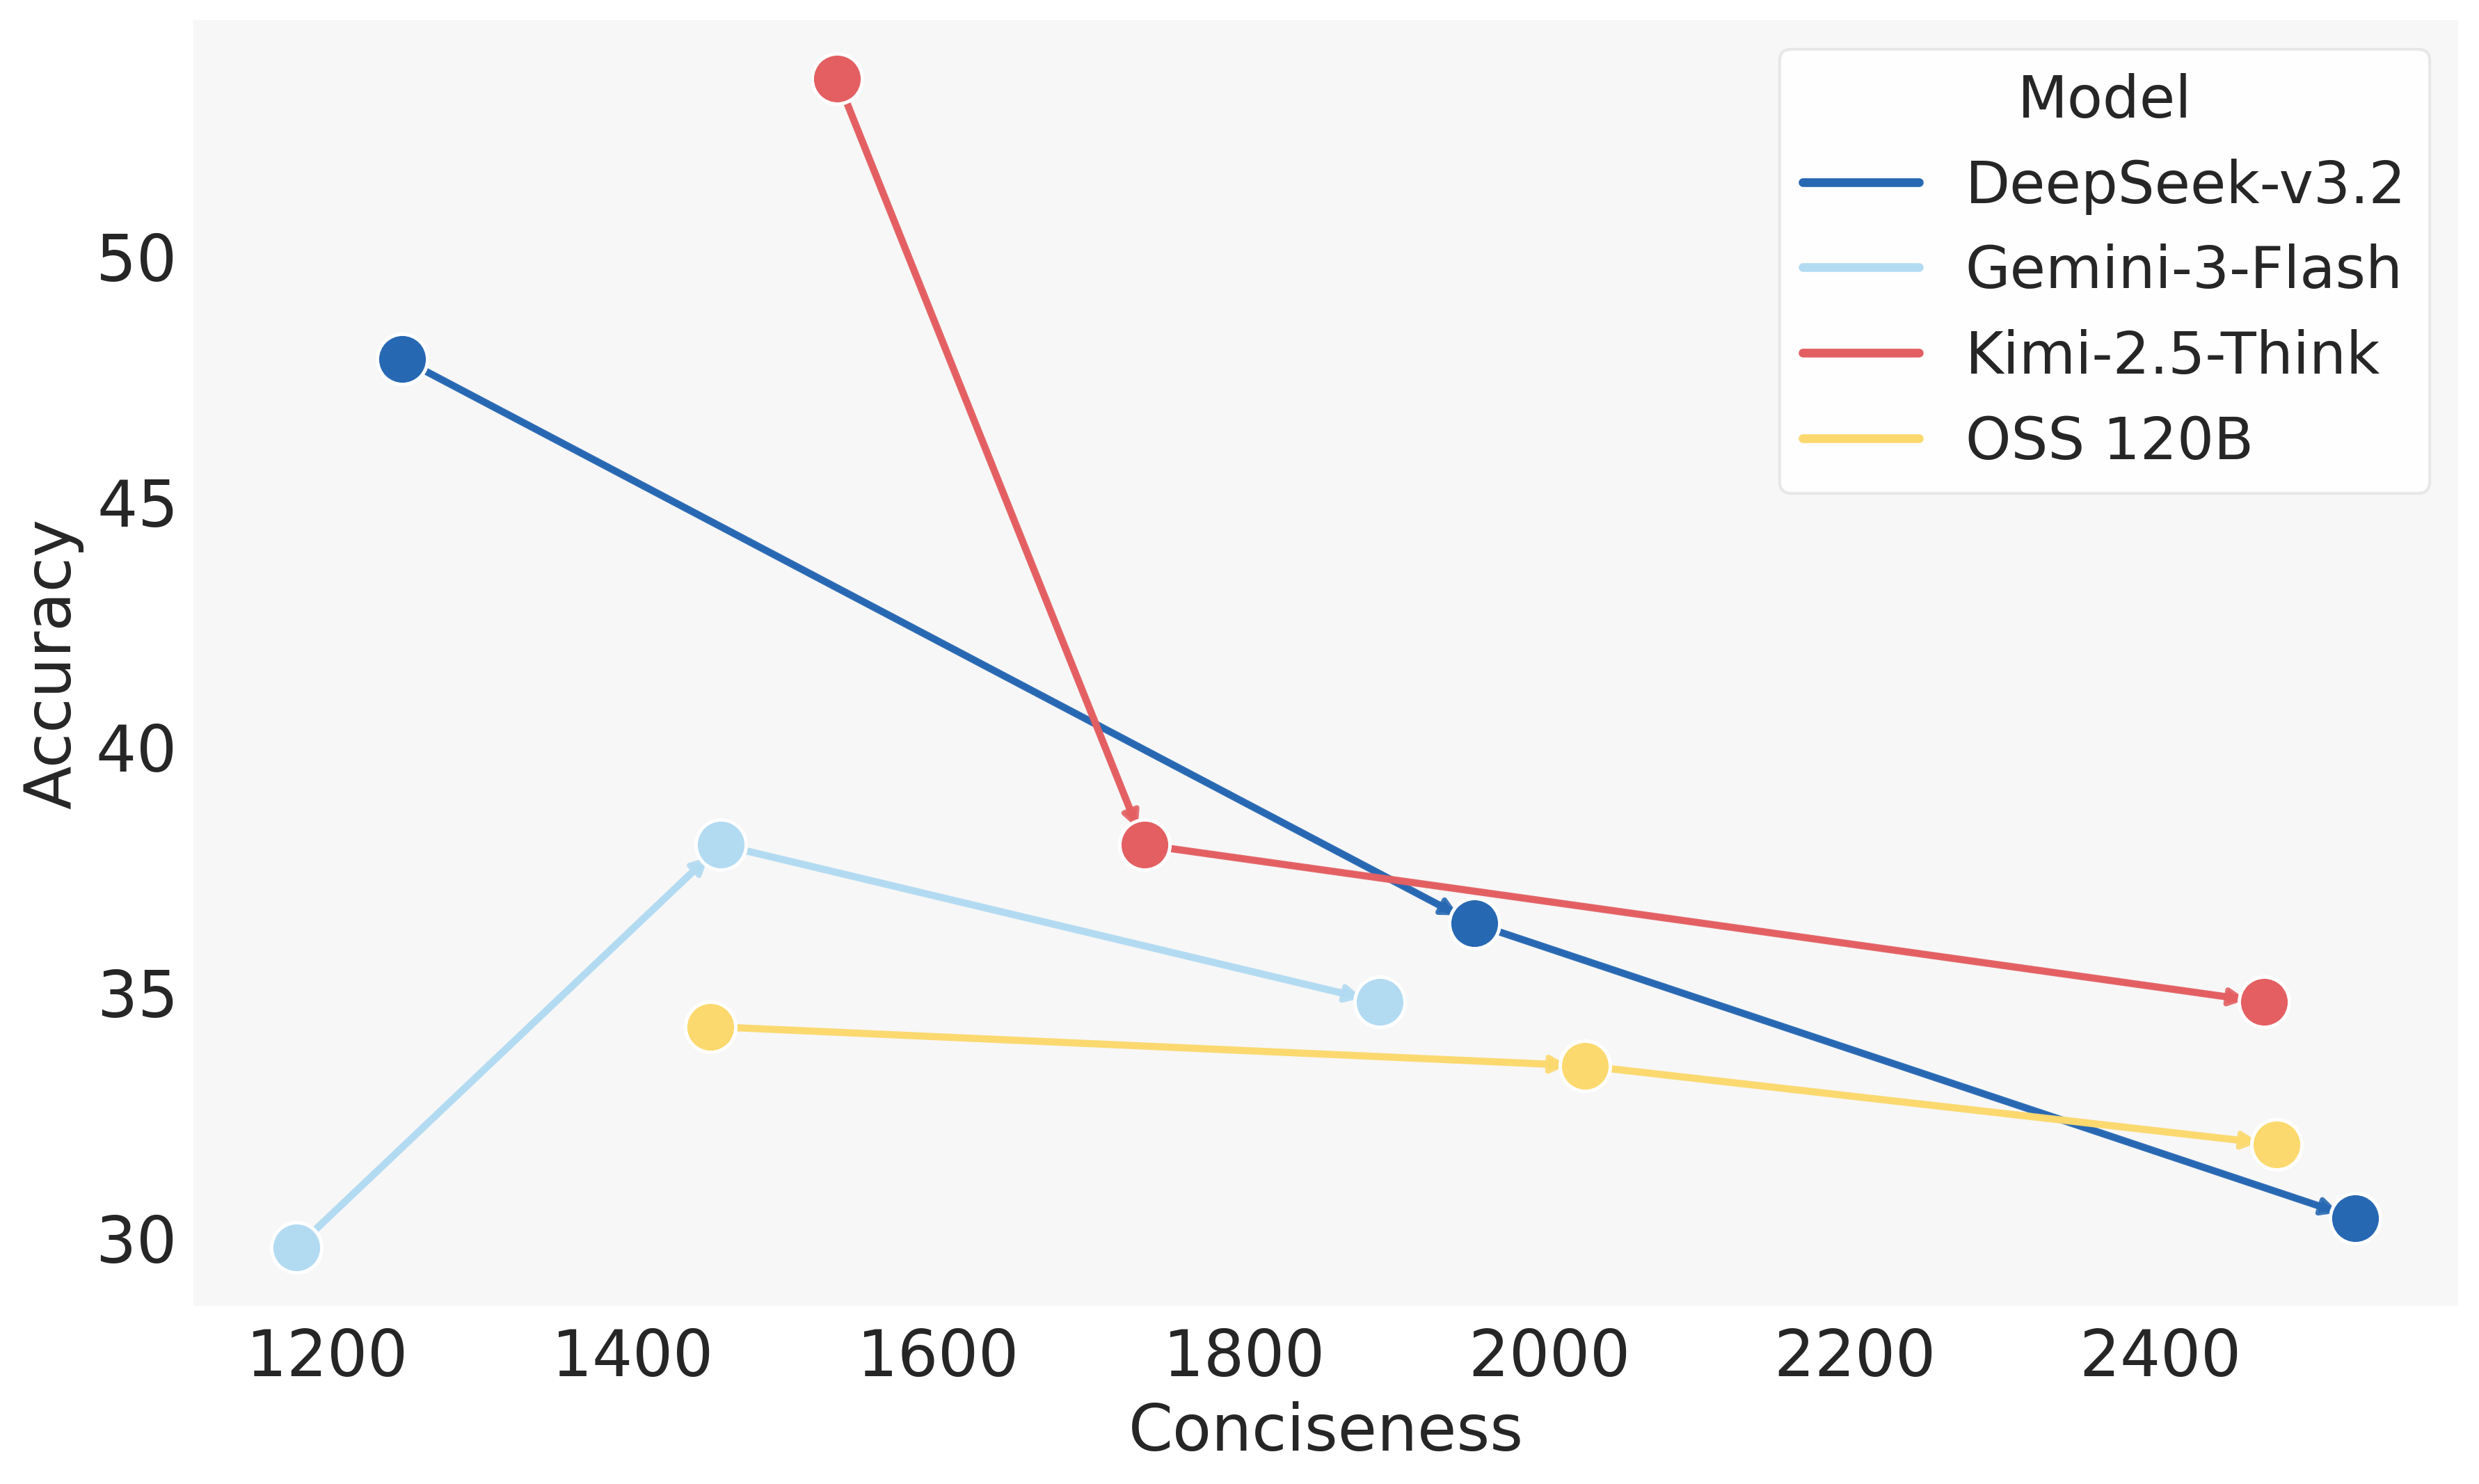

In [35]:
plot_prompt_progression(
    model_scores=elos,
    cols=columns,
    metric_x="conciseness",      # use your elo baseline column name
    metric_y="accuracy",         # works if baseline is plain "accuracy" OR "correct_accuracy"
    model_mapper=model_mapper,
    prompts=("correct", "anti_verbosity", "anti_verbosity_2"),  # example prompts to compare
    save_file="figures/prompt_delta_elo_accuracy.pdf",
    label_size=22,
    marker_size=300,
    width=14,
)